In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

In [2]:
img=cv2.imread('Images/road.bmp',cv2.IMREAD_GRAYSCALE).astype(np.float16)

Text(0.5, 1.0, 'Log Transformed Image')

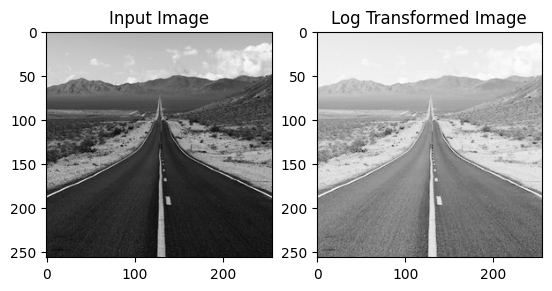

In [8]:
#log transformation
c=255/np.log(1+np.max(img))
height,width=img.shape
log_transformed=np.zeros((height,width))
for i in range(height):
    for j in range(width):
        log_transformed[i][j]=c*np.log(1+img[i][j])

plt.subplot(1,2,1)
plt.imshow(img,cmap='gray')
plt.title('Input Image')
plt.subplot(1,2,2)
plt.imshow(log_transformed,cmap='gray')
plt.title('Log Transformed Image')

In [3]:
def convolution(image, kernel):
 
    img_height, img_width = image.shape
    kernel_height, kernel_width = kernel.shape
    
    # Calculate padding
    pad_h = kernel_height // 2
    pad_w = kernel_width // 2
    
    # Pad the image with zeros
    padded_image = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant', constant_values=0)
    
    # Initialize output image
    output = np.zeros_like(image, dtype=np.float32)
    
    # Perform convolution
    for i in range(img_height):
        for j in range(img_width):
            # Extract the region of interest
            roi = padded_image[i:i+kernel_height, j:j+kernel_width]
        
            # Apply kernel (element-wise multiplication and sum)
            output[i, j] = np.sum(roi * kernel)
    
    return output

In [ ]:
def standard_average_filter(image):

    kernel = np.ones((3, 3)) / 9
    print("Standard Average Filter Kernel:")
    print(kernel)

    result = convolution(image, kernel)

    # Clip values to valid range
    result = np.clip(result, 0, 255)
    return result.astype(np.uint8)

avg_img=standard_average_filter(img)



Standard Average Filter Kernel:
[[0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]]


(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

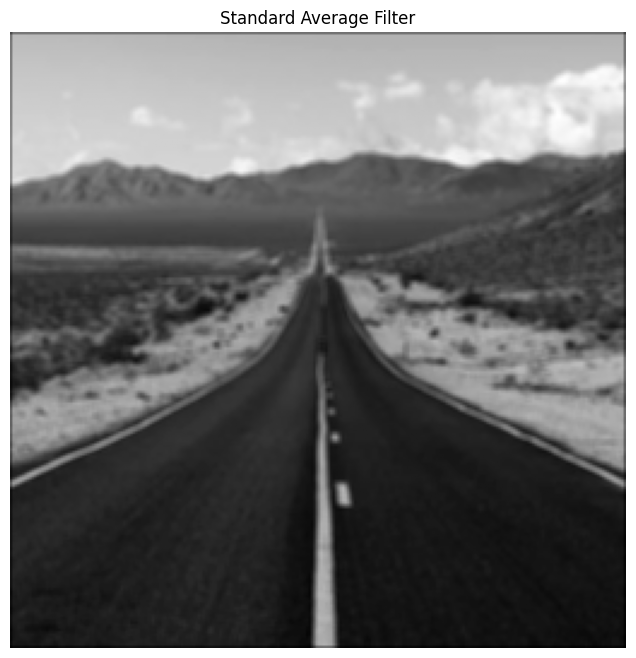

In [5]:
plt.figure(figsize=(12, 8))
plt.imshow(avg_img, cmap='gray')
plt.title('Standard Average Filter')
plt.axis('off')